# Bessel Functions and AC Power — the FM Spectrum Doesn't Change the Wattage

A phase/frequency-modulated tone splits its energy across a carrier and infinitely many
sidebands, with amplitude $J_n(\beta)$ (a Bessel function of the first kind) on the $n$-th
sideband. That looks like a totally different topic from AC power (RMS, $P=V_{rms}I_{rms}\cos\phi$),
but they are linked by one identity: $\sum_n J_n(\beta)^2 = 1$. Splitting a sinusoid into Bessel
sidebands can never change its **total power** — it only redistributes *where* in the spectrum
that power lives. Engines: `griffiths.bessel` (FM sidebands) and `dgs.ac_circuits` (AC power).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

from griffiths import bessel as bf
from dgs import ac_circuits as ac

print("griffiths.bessel + dgs.ac_circuits loaded")

griffiths.bessel + dgs.ac_circuits loaded


## §1 An FM tone is a sum of Bessel-weighted carriers

$$v(t) = V_0\cos\big(\omega_c t + \beta\sin\omega_m t\big) = V_0\sum_{n=-\infty}^{\infty} J_n(\beta)\cos\big[(\omega_c+n\omega_m)t\big]$$

This is the Jacobi-Anger expansion. `griffiths.bessel.fm_sideband_amplitudes(beta, n_max)`
returns $J_n(\beta)$ for the carrier ($n=0$) and the sidebands ($n\neq0$).

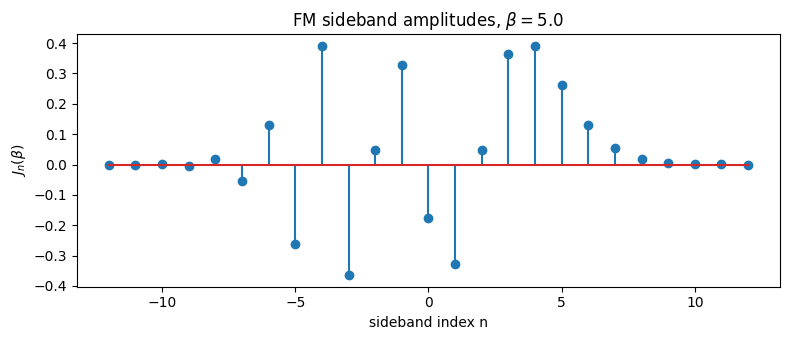

carrier amplitude J_0(beta) = -0.1775967713143383


In [2]:
V0, beta, n_max = 1.0, 5.0, 12
amps = bf.fm_sideband_amplitudes(beta, n_max)
ns = sorted(amps)
vals = np.array([amps[n] for n in ns])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.stem(ns, vals)
ax.set_xlabel("sideband index n"); ax.set_ylabel(r"$J_n(\beta)$")
ax.set_title(rf"FM sideband amplitudes, $\beta={beta}$")
plt.tight_layout(); plt.show()

print("carrier amplitude J_0(beta) =", amps[0])

## §2 Carrier nulls: where $J_0(\beta)=0$

At special modulation indices the carrier itself disappears ($J_0(\beta)=0$) and *all* the
power moves into the sidebands. `griffiths.bessel.carrier_null_indices` returns these $\beta$
as the zeros of $J_0$ -- the same `bessel_zeros(0, n)` that sets fiber/cylinder mode cutoffs
elsewhere in `griffiths.bessel`.

In [3]:
nulls = bf.carrier_null_indices(4)
print("carrier nulls at beta =", np.round(nulls, 3))

amps_null = bf.fm_sideband_amplitudes(float(nulls[0]), n_max)
print(f"at beta={nulls[0]:.3f}, carrier J_0 = {amps_null[0]:.2e} (should be ~0)")

carrier nulls at beta = [ 2.405  5.52   8.654 11.792]
at beta=2.405, carrier J_0 = -6.11e-17 (should be ~0)


## §3 $\sum_n J_n(\beta)^2 = 1$ -- the power-conservation identity

This is Bessel's analog of Parseval's theorem: redistributing power across sidebands never
changes the *total*. Verify it numerically for several $\beta$, then connect to AC power: the
total average power of $v(t)=V_0\cos(\cdot)$ into a resistor $R$ is $V_{rms}^2/R = (V_0^2/2)/R$
regardless of $\beta$ -- modulating the carrier moves power between spectral lines, the meter
on the resistor doesn't care.

In [4]:
for b in (0.5, 2.0, 5.0, 10.0):
    a = bf.fm_sideband_amplitudes(b, n_max=40)
    s = sum(v**2 for v in a.values())
    print(f"beta={b:5.1f}  sum J_n(beta)^2 = {s:.6f}  (expect 1.0)")

beta=  0.5  sum J_n(beta)^2 = 1.000000  (expect 1.0)
beta=  2.0  sum J_n(beta)^2 = 1.000000  (expect 1.0)
beta=  5.0  sum J_n(beta)^2 = 1.000000  (expect 1.0)
beta= 10.0  sum J_n(beta)^2 = 1.000000  (expect 1.0)


## §4 Same $V_{rms}$, same dissipated power, any modulation index

Synthesize $v(t)$ time-domain for a couple of $\beta$ values, drive it through a resistor
($i=v/R$), and confirm `dgs.ac_circuits.average_power` returns the *same* number each time --
the carrier-vs-sideband split is invisible to the power meter.

In [5]:
R = 50.0  # ohm
omega_c, omega_m = 2*np.pi*1000.0, 2*np.pi*50.0
t = np.linspace(0, 0.1, 20000)

for beta in (0.0, 2.405, 5.0, 8.654):  # includes a carrier null (first zero of J_0)
    v = V0 * np.cos(omega_c*t + beta*np.sin(omega_m*t))
    i = v / R
    P = ac.average_power(v, i, t)
    Vrms = ac.rms(v)
    print(f"beta={beta:6.3f}  V_rms={Vrms:.4f}  P_avg={P:.4f} W  (V0^2/2/R = {V0**2/2/R:.4f} W)")

beta= 0.000  V_rms=0.7071  P_avg=0.0100 W  (V0^2/2/R = 0.0100 W)
beta= 2.405  V_rms=0.7071  P_avg=0.0100 W  (V0^2/2/R = 0.0100 W)
beta= 5.000  V_rms=0.7071  P_avg=0.0100 W  (V0^2/2/R = 0.0100 W)
beta= 8.654  V_rms=0.7071  P_avg=0.0100 W  (V0^2/2/R = 0.0100 W)


## Summary

Bessel functions $J_n(\beta)$ tell you exactly how an FM/PM tone's power is *sliced* across the
carrier and sidebands ($\sum_n J_n(\beta)^2=1$), but the AC power identity $P=V_{rms}^2/R$ says
the *total* dissipated power in a resistor never moves — same physics, two unit systems, one
conservation law underneath both.